# 2_angry_mob_gpu1
training our tuning fork networks, setting to use gpu1 to avoid memory conflict with other notebooks needing gpu allocation

In [1]:
#### misc
import pandas as pd
import numpy as np
import os
from pathlib import Path
import pickle
import time
from itertools import product

#### graphical
import matplotlib.pyplot as plt

#### ML
import sklearn
from sklearn.decomposition import PCA
import tensorflow as tf
import keras
from keras import layers

#### custom
from InversePCA import InversePCA
from WMSE import WMSE, WMSE_metric

##### poke gpu
os.environ["CUDA_VISIBLE_DEVICES"]="1"

physical_devices = tf.config.list_physical_devices("GPU") 

gpu0usage = tf.config.experimental.get_memory_info("GPU:0")["current"]

print("Current GPU usage:\n"
     + " - GPU0: " + str(gpu0usage) + "B\n")

2024-02-09 16:30:26.323898: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-02-09 16:30:26.323929: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-02-09 16:30:26.324785: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-02-09 16:30:26.329552: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-02-09 16:30:26.902776: W tensorflow/compiler/tf2

Current GPU usage:
 - GPU0: 0B



2024-02-09 16:30:27.460793: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18447 MB memory:  -> device: 0, name: NVIDIA RTX A4500, pci bus id: 0000:61:00.0, compute capability: 8.6


## data prep
load in data and perform final prep (normalisation, label definition) before we start training)

In [2]:
#### path definition
path = Path(os.getcwd())
path = path.relative_to(*path.parts[:4])

#### load in grid
#df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/' + str(path) + '/data/df_all_log.h5', key='df')
df_full = pd.read_hdf('/home/oxs235/datastorage/repos_data/ojscutt/pitchfork/data/df_all_log.h5', key='df')

#### normalise/standardise
for column in df_full.columns:
    df_full[column+"_std"] = (df_full[column]-df_full[column].mean())/df_full[column].std()

df_full.describe()

#### define inputs
inputs = ['initial_mass_std', 'initial_Zinit_std', 'initial_Yinit_std', 'initial_MLT_std', 'log_star_age_std']

#### define outputs
classical_outputs = ['log_radius_std', 'log_luminosity_std', 'star_feh_std']
astero_outputs = [f'log_nu_0_{i+1}_std' for i in range(14,25)]

outputs = classical_outputs+astero_outputs

#### train/test split
seed = 42

df_train = df_full.sample(frac=0.995, random_state=seed)

df_train_inputs, df_val_inputs, df_train_outputs, df_val_outputs = sklearn.model_selection.train_test_split(df_train[inputs],df_train[outputs], test_size = 0.005, random_state=seed)

print("Training set: ", len(df_train_inputs))
print("Validation set: ", len(df_val_inputs))

#### can't have too many describes
df_full.describe()

Training set:  2424255
Validation set:  12183


,initial_mass,initial_Zinit,initial_Yinit,initial_MLT,star_age,radius,luminosity,effective_T,star_feh,nu_0_4,...,log_nu_0_31_std,log_nu_0_32_std,log_nu_0_33_std,log_nu_0_34_std,log_nu_0_35_std,log_nu_0_36_std,log_nu_0_37_std,log_nu_0_38_std,log_nu_0_39_std,log_nu_0_40_std
count,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,...,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06,2.448681e+06
mean,1.021885e+00,1.440698e-02,2.814693e-01,2.117984e+00,5.000177e+00,1.312728e+00,2.116482e+00,5.870890e+03,-1.127145e-01,5.459277e+02,...,5.100371e-15,3.629539e-15,2.700240e-15,1.435547e-15,-4.423639e-15,8.003407e-15,-8.417543e-15,1.289578e-15,-3.185318e-15,3.670395e-15
std,1.175610e-01,9.677123e-03,2.805593e-02,2.879175e-01,3.405371e+00,4.813547e-01,1.572419e+00,5.674285e+02,3.499532e-01,2.021373e+02,...,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,8.000000e-01,3.869061e-03,2.400000e-01,1.700000e+00,2.966411e-02,6.990236e-01,1.321735e-01,4.099787e+03,-1.077903e+00,1.545097e+02,...,-2.605045e+00,-2.599363e+00,-2.594960e+00,-2.591708e+00,-2.589646e+00,-2.588901e+00,-2.589287e+00,-2.590747e+00,-2.593002e+00,-2.595848e+00
25%,9.200000e-01,6.471429e-03,2.600000e-01,1.900000e+00,2.309880e+00,9.719693e-01,9.371542e-01,5.495672e+03,-4.000000e-01,3.986516e+02,...,-5.612334e-01,-5.643108e-01,-5.676179e-01,-5.705508e-01,-5.723483e-01,-5.730070e-01,-5.725672e-01,-5.713737e-01,-5.700038e-01,-5.685747e-01
50%,1.040000e+00,1.077191e-02,2.800000e-01,2.100000e+00,4.275231e+00,1.160016e+00,1.698469e+00,5.863863e+03,-1.000000e-01,5.591040e+02,...,2.414913e-01,2.417789e-01,2.415099e-01,2.405877e-01,2.389688e-01,2.369176e-01,2.348740e-01,2.333131e-01,2.326247e-01,2.327753e-01
75%,1.120000e+00,2.007835e-02,3.000000e-01,2.300000e+00,7.159688e+00,1.498369e+00,2.883064e+00,6.223793e+03,1.837200e-01,6.947397e+02,...,7.562359e-01,7.569644e-01,7.578097e-01,7.587334e-01,7.595544e-01,7.599729e-01,7.598420e-01,7.591873e-01,7.580180e-01,7.566985e-01
max,1.200000e+00,3.897971e-02,3.200000e-01,2.500000e+00,1.399997e+01,2.873431e+00,1.163902e+01,7.998610e+03,5.094573e-01,1.021990e+03,...,1.616724e+00,1.617024e+00,1.618137e+00,1.620054e+00,1.622624e+00,1.625764e+00,1.629202e+00,1.632519e+00,1.633559e+00,1.635647e+00


## pca
here's where I define pca components that are required to save our networks (they construct the inversePCA layer)

this is a nice time to do a comparison on how much including the classical observables in the pca process affects how many components we need to include for a reasonable level of explained variance!

Explained variance ratio with n_comps = 1 is 0.6577451749609726
Explained variance ratio with n_comps = 2 is 0.9714930131119861
Explained variance ratio with n_comps = 3 is 1.0
Explained variance ratio with n_comps = 1 is 0.9999909328391123
Explained variance ratio with n_comps = 2 is 0.9999990454182259
Explained variance ratio with n_comps = 3 is 0.9999996962093982


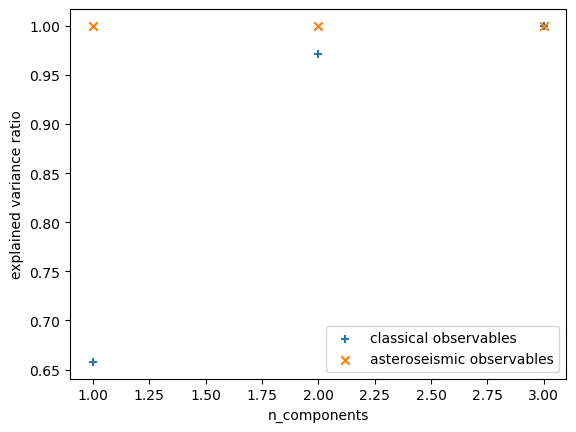

In [12]:
"""
pca comparison
"""
###### classical outs
### define pca global vars
df_outs = df_full[classical_outputs]
seed = 42

### arrays for plot loop
classical_evr_arr = np.zeros(len(classical_outputs))
n_arr = np.arange(1,len(classical_outputs)+1)

### plot loop
i=0
for n in n_arr:
    n_components = n
    pca = PCA(n_components=n_components, random_state=seed)
    pca.fit(df_outs)
    print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))
    classical_evr_arr[i] = sum(pca.explained_variance_ratio_)
    i+=1

###### astero_outs
### define pca global vars
df_outs = df_full[astero_outputs]

### arrays for plot loop
astero_evr_arr = np.zeros(len(classical_outputs))

### plot loop
i=0
for n in n_arr:
    n_components = n
    pca = PCA(n_components=n_components, random_state=seed)
    pca.fit(df_outs)
    print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))
    astero_evr_arr[i] = sum(pca.explained_variance_ratio_)
    i+=1
    
plt.scatter(n_arr, classical_evr_arr, marker='+', label='classical observables')
plt.scatter(n_arr, astero_evr_arr, marker='x',label='asteroseismic observables')
plt.ylabel('explained variance ratio')
plt.xlabel('n_components')
plt.legend()

In [5]:
"""
pca
"""
#### define pca global vars
n_components = 4
seed = 42

#### define and fit pca
pca = PCA(n_components=n_components, random_state=seed)
pca.fit(df_full[astero_outputs])

#### print variance with chosen n_comps
print("Explained variance ratio with n_comps = " + str(n_components) + " is " + str(sum(pca.explained_variance_ratio_)))

Explained variance ratio with n_comps = 4 is 0.999999896009264


In [6]:
"""
DEFINE WEIGHTS FOR WMSE
"""
log_weights = (1/np.log(10)) * np.array([0.01, 0.02, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1] / df_full[["radius", "luminosity"] + [f'nu_0_{i+1}' for i in range(14,25)]].mean())

log_weights = log_weights / df_full[["log_radius", "log_luminosity"] + [f'log_nu_0_{i+1}' for i in range(14,25)]].std()

unlog_weights = [0.1] / df_full['star_feh'].std()

weights = log_weights.values[[0,1]].tolist() + unlog_weights.tolist() + log_weights.values[2:].tolist()

print(weights)

[0.02324560601067967, 0.012220076304794422, 0.2857524907848119, 0.00012220154533326764, 0.00011530706805035573, 0.000109209187475727, 0.00010373957827574545, 9.877493746324607e-05, 9.424043658607474e-05, 9.008674371702482e-05, 8.626668769588676e-05, 8.273438289926203e-05, 7.944721575439512e-05, 7.636537366843286e-05]


## gridsearch parameters
define gridsearch parameters for the tuning/pitchfork setup, focus on hparams that alter overarching architecture

In [7]:
"""
DEFINE TARGET ARCHITECTURES FOR GRID SEARCH
Rerun after training to avoid "___ not iterable" errors
"""
stem_d_layers = [4]
stem_d_units = [64]

ctine_d_layers = [6]
ctine_d_units = [64]

atine_d_layers = [6]
atine_d_units = [256]

archs = pd.DataFrame(product(stem_d_layers, stem_d_units, ctine_d_layers, ctine_d_units, atine_d_layers, atine_d_units))

archs.columns = ['stem_d_layers', 'stem_d_units', 'ctine_d_layers', 'ctine_d_units', 'atine_d_layers', 'atine_d_units']

In [8]:
"""
        ________
_______/
       \________
| stem | tines |

"""


tf.keras.backend.clear_session()

for i in range(1000):
    for arch_i in range(len(archs)):
        tf.keras.backend.clear_session()
        arch = archs.iloc[[arch_i]]
        
        ######## stem
        #### input
        stem_input = keras.Input(shape=(len(inputs),))
    
        #### dense layers
        stem_d_layers = arch["stem_d_layers"].iloc[0]
        stem_d_units = arch["stem_d_units"].iloc[0]
    
        for stem_d_layer in range(stem_d_layers):
            if stem_d_layer == 0:
                stem = layers.Dense(stem_d_units, activation='relu')(stem_input)
                stem = layers.LayerNormalization()(stem)
            else:
                stem = layers.Dense(stem_d_units, activation='relu')(stem)
                stem = layers.LayerNormalization()(stem)
    
        ######## classical tine
        #### dense layers
        ctine_d_layers = arch["ctine_d_layers"].iloc[0]
        ctine_d_units = arch["ctine_d_units"].iloc[0]
    
        for ctine_d_layer in range(ctine_d_layers):
            if ctine_d_layer == 0:
                ctine = layers.Dense(ctine_d_units, activation='relu')(stem)
                ctine = layers.LayerNormalization()(ctine)
            else:
                ctine = layers.Dense(ctine_d_units, activation='relu')(ctine)
                ctine = layers.LayerNormalization()(ctine)
    
        #### output
        ctine_out = layers.Dense(len(classical_outputs),name='classical_outs')(ctine)
    
    
        ######## astero tine
        #### dense layers
        atine_d_layers = arch["atine_d_layers"].iloc[0]
        atine_d_units = arch["atine_d_units"].iloc[0]
        
        for atine_d_layer in range(atine_d_layers):
            if atine_d_layer == 0:
                atine = layers.Dense(atine_d_units, activation='relu')(stem)
                atine = layers.LayerNormalization()(atine)
            else:
                atine = layers.Dense(atine_d_units, activation='relu')(atine)
                atine = layers.LayerNormalization()(atine)
    
        #### output
        atine = layers.Dense(int(len(pca.components_)))(atine)
        atine_out = InversePCA(pca_comps = pca.components_, pca_mean = pca.mean_, name='asteroseismic_outs')(atine)
    
        ######## construct and fit
        model = keras.Model(inputs=stem_input, outputs=[ctine_out, atine_out], name='tuning_fork')
    
        #### compile model
        optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)
    
            
        model.compile(loss=[WMSE(weights[:3]), WMSE(weights[3:])], optimizer=optimizer)
        
        #### fit model
        arch_name = "pitchfork_"+str(i)
    
        log_dir = "/home/oxs235/datastorage/repos_data/" + str(path) + "/logs/angry_mob_1/" + arch_name
    
        def scheduler(epoch, lr):
            if lr < 5e-6:
                return lr
            else:
                return lr * tf.math.exp(-0.1)
    
        lr_callback = tf.keras.callbacks.LearningRateScheduler(scheduler, verbose=0)
                                                           
        cp_callback = tf.keras.callbacks.ModelCheckpoint("/home/oxs235/datastorage/repos_data/" + str(path) + "/models/angry_mob_1/" + arch_name + ".h5",
                                                         monitor= 'val_loss',
                                                         save_best_only= False,
                                                         save_freq='epoch')    
    
        tb_callback = tf.keras.callbacks.TensorBoard(log_dir=log_dir) 
    
        history = model.fit(df_train_inputs,
                            [df_train_outputs[classical_outputs],df_train_outputs[astero_outputs]],
                            validation_data=(df_val_inputs,[df_val_outputs[classical_outputs], df_val_outputs[astero_outputs]]),
                            batch_size=2**14,
                            verbose=1,
                            epochs=50,
                            callbacks=[lr_callback, cp_callback, tb_callback],
                            shuffle=True
                           )  

2024-02-09 16:33:59.751629: I external/local_tsl/tsl/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory


Epoch 1/50


2024-02-09 16:34:02.743471: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8904
2024-02-09 16:34:02.918783: I external/local_xla/xla/service/service.cc:168] XLA service 0x7fa0dcb98320 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2024-02-09 16:34:02.918804: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA RTX A4500, Compute Capability 8.6
2024-02-09 16:34:02.923754: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1707496442.999707 3448754 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


148/148 [==============================] - 9s 27ms/step - loss: 32643942.0000 - classical_outs_loss: 458.2545 - inverse_pca_loss: 32643464.0000 - val_loss: 3236773.7500 - val_classical_outs_loss: 85.4478 - val_inverse_pca_loss: 3236688.0000 - lr: 0.0090
Epoch 2/50
  4/148 [..............................] - ETA: 3s - loss: 2799764.5000 - classical_outs_loss: 77.0188 - inverse_pca_loss: 2799687.5000

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


...

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 4s 25ms/step - loss: 2288899.2500 - classical_outs_loss: 54.7535 - inverse_pca_loss: 2288843.7500 - val_loss: 1369218.6250 - val_classical_outs_loss: 39.6817 - val_inverse_pca_loss: 1369179.0000 - lr: 0.0082
Epoch 3/50
148/148 [==============================] - 4s 24ms/step - loss: 1547165.2500 - classical_outs_loss: 40.2145 - inverse_pca_loss: 1547123.8750 - val_loss: 1035593.5625 - val_classical_outs_loss: 34.1072 - val_inverse_pca_loss: 1035559.4375 - lr: 0.0074
Epoch 4/50
148/148 [==============================] - 4s 25ms/step - loss: 1100379.2500 - classical_outs_loss: 30.9480 - inverse_pca_loss: 1100348.3750 - val_loss: 998221.3125 - val_classical_outs_loss: 31.2768 - val_inverse_pca_loss: 998190.0625 - lr: 0.0067
Epoch 5/50
148/148 [==============================] - 4s 25ms/step - loss: 907254.1250 - classical_outs_loss: 28.0354 - inverse_pca_loss: 907225.6875 - val_loss: 748481.4375 - val_classical_outs_loss: 23.4661 - val_inverse_pca_

/home/oxs235/miniconda3/envs/pitchfork/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


148/148 [==============================] - 4s 25ms/step - loss: 1992032.7500 - classical_outs_loss: 62.3577 - inverse_pca_loss: 1991970.2500 - val_loss: 1150011.7500 - val_classical_outs_loss: 36.3111 - val_inverse_pca_loss: 1149975.5000 - lr: 0.0082
Epoch 3/50
148/148 [==============================] - 4s 25ms/step - loss: 1423407.6250 - classical_outs_loss: 41.9917 - inverse_pca_loss: 1423365.5000 - val_loss: 1221573.3750 - val_classical_outs_loss: 30.6820 - val_inverse_pca_loss: 1221542.7500 - lr: 0.0074
Epoch 4/50
148/148 [==============================] - 4s 25ms/step - loss: 1016561.3750 - classical_outs_loss: 27.7260 - inverse_pca_loss: 1016533.6875 - val_loss: 1260655.7500 - val_classical_outs_loss: 30.5252 - val_inverse_pca_loss: 1260625.2500 - lr: 0.0067
Epoch 5/50
148/148 [==============================] - 4s 25ms/step - loss: 805081.1875 - classical_outs_loss: 21.7372 - inverse_pca_loss: 805059.3750 - val_loss: 574233.3125 - val_classical_outs_loss: 17.4283 - val_inverse_pc

KeyboardInterrupt: 